In [ ]:
#pip install "pip<24.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 14.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
#!pip install trajectoryclusteringanalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.8/178.8 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.2/528.2 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 M

In [7]:
import sys
sys.path.append(r"C:\Users\imen.miloudi\Documents\stage\TrajectoryClusteringAnalysis\src")

In [9]:
import trajectoryclusteringanalysis

print("Le package est bien importé :", trajectoryclusteringanalysis)

Le package est bien importé : <module 'trajectoryclusteringanalysis' from 'C:\\Users\\imen.miloudi\\Documents\\stage\\TrajectoryClusteringAnalysis\\src\\trajectoryclusteringanalysis\\__init__.py'>


In [10]:
print(trajectoryclusteringanalysis.__version__)

0.0.2a1


In [13]:
import pandas as pd
df = pd.read_csv(r'C:\Users\imen.miloudi\Documents\stage\TrajectoryClusteringAnalysis\data\mvad_data.csv')
df.insert(0, 'id', df.index)
df.head()

,id,Sep.93,Oct.93,Nov.93,Dec.93,Jan.94,Feb.94,Mar.94,Apr.94,May.94,...,Sep.98,Oct.98,Nov.98,Dec.98,Jan.99,Feb.99,Mar.99,Apr.99,May.99,Jun.99
0,0,EM,EM,EM,EM,TR,TR,EM,EM,EM,...,EM,EM,EM,EM,EM,EM,EM,EM,EM,EM
1,1,FE,FE,FE,FE,FE,FE,FE,FE,FE,...,HE,HE,HE,HE,HE,HE,HE,HE,HE,HE
2,2,TR,TR,TR,TR,TR,TR,TR,TR,TR,...,EM,EM,EM,EM,EM,EM,EM,EM,JL,JL
3,3,TR,TR,TR,TR,TR,TR,TR,TR,TR,...,EM,JL,JL,JL,JL,JL,JL,JL,JL,JL
4,4,FE,FE,FE,FE,FE,FE,FE,FE,FE,...,HE,HE,HE,HE,HE,HE,HE,HE,HE,HE


In [14]:
from trajectoryclusteringanalysis.tca import TCA

In [15]:
tca = TCA(data=df,
              index_col='id',
              alphabet=["EM", "FE", "HE", "JL", "SC", "TR"],
              states=["employment", "FE", "HE", "joblessness","school", "training"],
              mode='unidimensional',)

INFO:root:TCA object initialized successfully
INFO:root:The unidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (712, 71)
state coding:
   alphabet        label  label encoded
0       EM   employment              1
1       FE           FE              2
2       HE           HE              3
3       JL  joblessness              4
4       SC       school              5
5       TR     training              6


In [16]:
distance_matrix = tca.compute_distance_matrix(tca.data,metric='hamming', substitution_cost_matrix=None)
print("distance matrix :\n",distance_matrix)

INFO:root:Calculating distance matrix using metric: hamming...
INFO:root:Time taken for computation: 0.06 seconds


distance matrix :
 [[0.         1.         0.82857143 ... 0.97142857 0.31428571 0.8       ]
 [1.         0.         0.82857143 ... 0.2        1.         1.        ]
 [0.82857143 0.82857143 0.         ... 0.85714286 0.54285714 0.51428571]
 ...
 [0.97142857 0.2        0.85714286 ... 0.         0.97142857 1.        ]
 [0.31428571 1.         0.54285714 ... 0.97142857 0.         0.51428571]
 [0.8        1.         0.51428571 ... 1.         0.51428571 0.        ]]


In [17]:
substitution_cost_matrix=tca.compute_substitution_cost_matrix(method='constant')
substitution_cost_matrix

,EM,FE,HE,JL,SC,TR
EM,0.0,2.0,2.0,2.0,2.0,2.0
FE,2.0,0.0,2.0,2.0,2.0,2.0
HE,2.0,2.0,0.0,2.0,2.0,2.0
JL,2.0,2.0,2.0,0.0,2.0,2.0
SC,2.0,2.0,2.0,2.0,0.0,2.0
TR,2.0,2.0,2.0,2.0,2.0,0.0


In [19]:
distance_matrix = tca.compute_distance_matrix(tca.data,metric='optimal_matching', substitution_cost_matrix=substitution_cost_matrix,indel_cost=2.0)
print("distance matrix :\n",distance_matrix)

INFO:root:Calculating distance matrix using metric: optimal_matching...


User-provided indel cost: 2.0
substitution cost matrix: 
      EM   FE   HE   JL   SC   TR
EM  0.0  2.0  2.0  2.0  2.0  2.0
FE  2.0  0.0  2.0  2.0  2.0  2.0
HE  2.0  2.0  0.0  2.0  2.0  2.0
JL  2.0  2.0  2.0  0.0  2.0  2.0
SC  2.0  2.0  2.0  2.0  0.0  2.0
TR  2.0  2.0  2.0  2.0  2.0  0.0


100%|██████████| 712/712 [31:53<00:00,  2.69s/it] 
INFO:root:Time taken for computation: 1913.65 seconds


distance matrix :
 [[0.         2.         1.65714286 ... 1.94285714 0.62857143 1.6       ]
 [2.         0.         1.65714286 ... 0.4        2.         2.        ]
 [1.65714286 1.65714286 0.         ... 1.71428571 1.08571429 1.02857143]
 ...
 [1.94285714 0.4        1.71428571 ... 0.         1.94285714 2.        ]
 [0.62857143 2.         1.08571429 ... 1.94285714 0.         1.02857143]
 [1.6        2.         1.02857143 ... 2.         1.02857143 0.        ]]


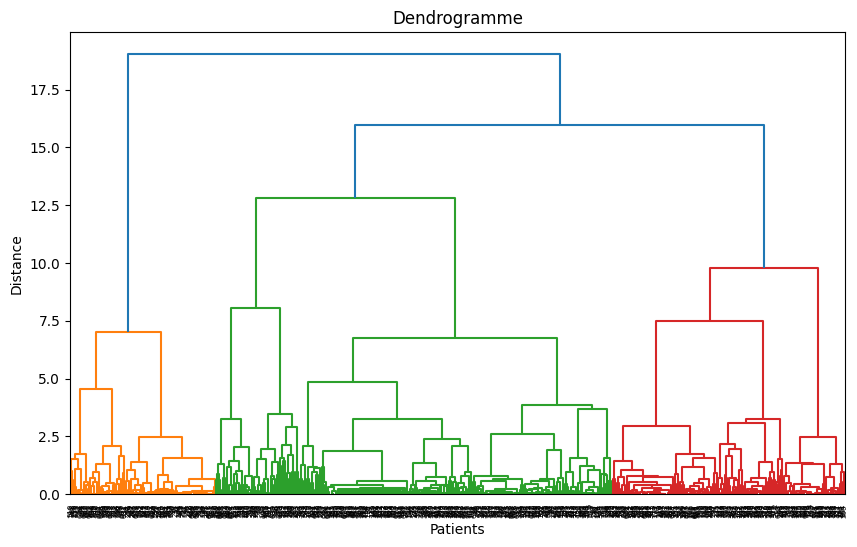

In [ ]:
linkage_matrix = tca.hierarchical_clustering(distance_matrix)
tca.plot_dendrogram(linkage_matrix,title='Dendrogramme')

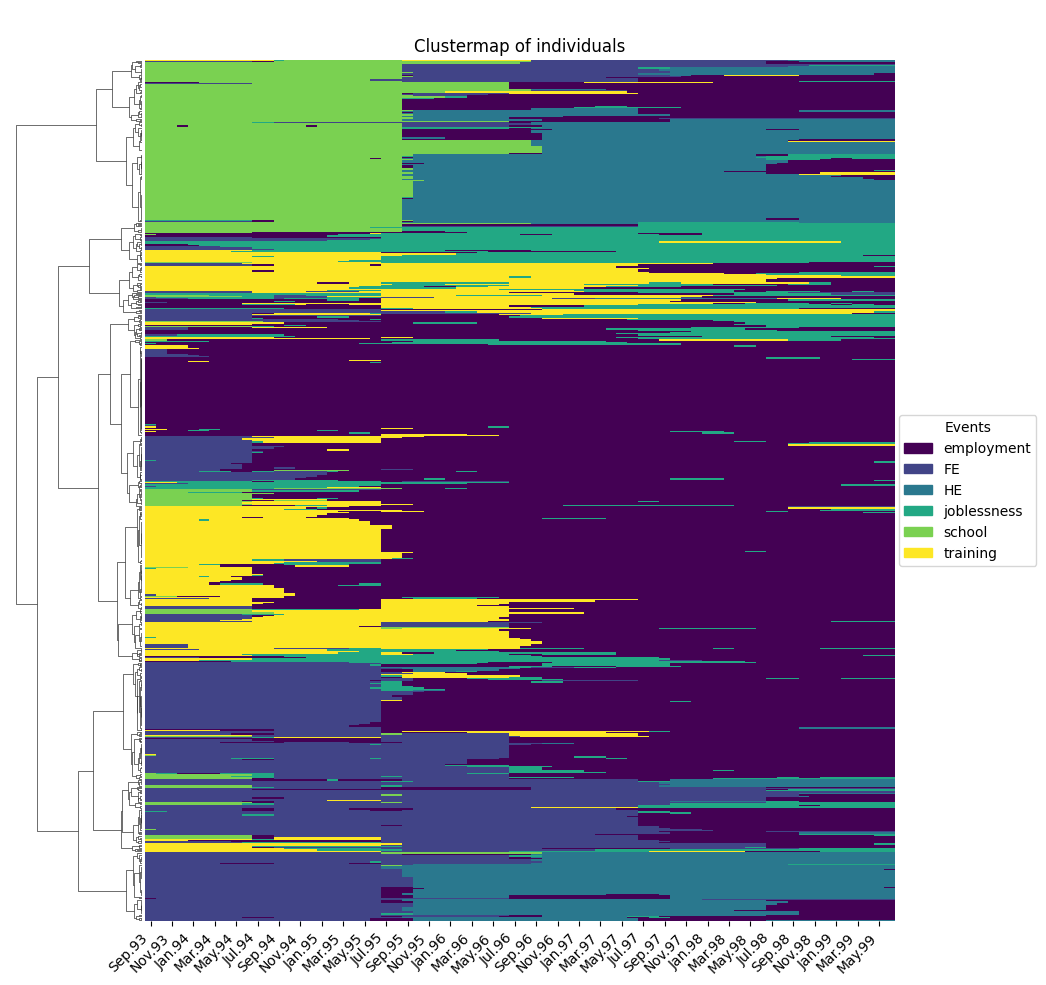

In [ ]:
tca.plot_clustermap(tca.data,linkage_matrix)